# Tutorial 2: From Sine Waves to the Fourier Series

**Week 2, Day 2: Signal Processing**

**By Neuromatch Academy (community contribution)**

**Content Creators:** *to be filled in*

**Content Reviewers:** *to be filled in*

**Production editors:** *to be filled in*

---


# Tutorial Objectives

*Estimated timing of tutorial: to be filled in*

This tutorial builds the core intuition behind Fourier analysis from the ground up. We start with the **sine wave** — the elementary building block of every signal — and learn how its three parameters (amplitude, frequency, phase) shape it. We then **decompose** a signal into a sum of sine waves, seeing how a handful of weighted components combine to reproduce a target. Finally, we use this idea to build the **Fourier series**: writing familiar periodic waveforms (square and sawtooth) as sums of harmonically related sines, watching the approximation converge as we add more terms, and even building an *aperiodic* Gaussian pulse the same way — where the **phase** alone decides whether the result is a sharp spike or noise.

By the end of this tutorial you will be able to:

- Describe a sine wave in terms of amplitude, frequency, and phase
- Reconstruct a target signal as a weighted sum of sine waves plus a DC offset
- Read a magnitude spectrum and relate it to the time-domain components
- Explain how negative coefficients correspond to a phase shift of $\pi$
- Build square and sawtooth waves from their Fourier components
- Reason about how the rate of coefficient decay controls convergence (and the Gibbs phenomenon)
- See how an aperiodic pulse is built from sine waves, and how phase alone separates a sharp spike from noise

---


# Setup

## Install and import feedback gadget

In [1]:
# @title Install and import feedback gadget
!pip3 install vibecheck datatops --quiet
!pip3 install remfile h5py --quiet
from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "neuromatch_cn",
            "user_key": "y1x3mpx5",
        },
    ).render()
feedback_prefix = "W2D2_T2"


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Imports

In [2]:
# @title Imports
# General
import io
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ipywidgets as widgets
from IPython.display import display#, Markdown, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

# Change of Basis
from matplotlib.patches import Wedge

#Sine waves
from scipy.integrate import quad

# Spectral Analysis
import remfile, h5py
from scipy import signal
from scipy.fft import fft, fftfreq


/opt/venvs/cocalc/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Figure Settings

In [11]:
# @title Figure Settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

## Helper Functions

In [4]:
# @title Helper Functions

# Each interactive demo in this tutorial is fully self-contained (its config,
# time base, and callbacks live inside its own function), so no shared helper
# functions are required here.

# Part 1: Change_of_Basis


## Basis in 2D

**Definition**:

A set of vectors {$\mathbf{e_1},\mathbf{e_2}$} is a basis for $\mathbb{R}^2$ if:


1. They are linearly independent, i.e., if the equation:

   $$c_1 \mathbf{e_1} + c_2 \mathbf{e_2} = 0$$
   is only satisfied when both $c_1$ and $c_2$ are zero.

   In $\mathbb{R}^2$ this intuitively means that the two vectors that form a basis cannot have the same direction.
2. Every vector $\mathbf{v}$ in $\mathbb{R}^2$ can be written as their linear combination:
   $$\mathbf{v} = d_1\mathbf{e_1} + d_2\mathbf{e_2}$$ for some $d_1$, $d_2$, which are called the coordinates in this basis.


Futher, if the dot product of basis vectors is zero ($\mathbf{e_1} \cdot \mathbf{e_2} = 0$) such a basis is called *orthogonal*.

If vectors $\mathbf{e_1}$ and $\mathbf{e_2}$ forming orthogonal basis also have unit length ($\mathbf{e_1} ⋅ \mathbf{e_1} = \mathbf{e_2} ⋅\mathbf{e_2} = 1$), such a basis is then called *orthonormal*.






##Think!

* What are the advantages of orthogonal basis and orthonormal basis compared to the arbitraty one?

* Are vectors $\mathbf{e_1} = \begin{bmatrix} 1\\0 \end{bmatrix}$, $\mathbf{e_2} = \begin{bmatrix} 2\\1 \end{bmatrix}$ forming a basis? Is it orthogonal? Orthonormal?

* What about $\mathbf{e_1} = \begin{bmatrix} sin(\pi/4)\\ cos(\pi/4) \end{bmatrix}$, $\mathbf{e_2} = \begin{bmatrix} -sin(\pi/4)\\cos(\pi/4) \end{bmatrix}$?


There are many different basis one could use to achieve one's goal

## Coordinate systems

A coordinate system on $\mathbb{R}^2$ consisnts of:


1.   **An origin** - reference point (0,0)
2.   **A basis**
3.   **Coordinates**

So any point can be uniquely represented by its coordinate vector $\mathbf{v}$:
$$\mathbf{v} = d_1 \mathbf{e_1} + d_2 \mathbf{e_2}$$



The most common coordinate system is **Cartesian (Standard)**:

*   Basis: $\mathbf{e_1} = \begin{bmatrix} 1\\0 \end{bmatrix}$ - hoizonal or "x" direction , $\mathbf{e_2} = \begin{bmatrix} 0\\1 \end{bmatrix}$ - vertical or "y" direction.
*   Any point can then be expressed by specifying numbers x and y such that:

$$\mathbf{v} = x\mathbf{e_1} + y \mathbf{e_2}$$

Among Standard coordinate system there are many more others.

**Polar coordinate system**
*   Points are specifyed by the radius $ r = \sqrt{x^2 + y^2}$ from the origin and angle $ϕ  = \arctan{\frac{y}{x}}$ from x-axis.
*   Basis: $\mathbf{e_1} = \begin{bmatrix} \cos{ϕ}\\ \sin{ϕ} \end{bmatrix} = \begin{bmatrix} \frac{x}{r}\\ \frac{y}{r} \end{bmatrix}$,  $\mathbf{e_2} = \begin{bmatrix} -\sin{ϕ}\\ \cos{ϕ} \end{bmatrix} = \begin{bmatrix} -\frac{y}{r}\\ \frac{x}{r} \end{bmatrix}$

*   Any point can then be expressed by specifying numbers $r$ and $ϕ$ such that $\mathbf{v} = d_r \mathbf{e_1} + d_ϕ \mathbf{e_2}$












### Interactive Demo 1: Change of Basis

Changing the coordinate system is essentially the same as changing the basis in which you are looking at the porblem. Although it is possible to make any basis work for you task, in some coordinate systems the solution is easier to obtain.

In the following demo you will try different bases to achieve a relatevily simple task: draw pizza slice by moving the red dot along chosen basis vectors.


Which basis is the most convenient for this task? Do not hesitate t change the basis if you fell frustrated!

In [5]:
#@markdown Make sure you execute this cell to enable the widget!

# -----------------------------
# initial state
# -----------------------------
x0, y0 = 1.0, 0.0
x, y = x0, y0


x_lims = (-.2, 1.2)
y_lims = (-.2, 1)


x_history = [x]
y_history = [y]


# -----------------------------
# widgets
# -----------------------------
basis_selector = widgets.ToggleButtons(
    options=['Non-orthogonal', 'Orthogonal', 'Polar'],
    value='Non-orthogonal',
)


d1_input = widgets.FloatText(
    value=0.0,
    description='Change along e1:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)


d2_input = widgets.FloatText(
    value=0.0,
    description='Change along e2:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)


move_e1_button = widgets.Button(
    description='Move along e1',
    layout=widgets.Layout(width='200px')
)


move_e2_button = widgets.Button(
    description='Move  along e2',
    layout=widgets.Layout(width='200px')
)


out = widgets.Output(
    layout=widgets.Layout(width='500px')
)


# -----------------------------
# helpers
# -----------------------------
def reset_task():
    global x, y, x_history, y_history
    x, y = x0, y0
    x_history = [x]
    y_history = [y]
    d1_input.value = 0.0
    d2_input.value = 0.0


def get_basis_vectors():
    mode = basis_selector.value

    if mode == 'Orthogonal':
        e1 = np.array([1.0, 0.0])
        e2 = np.array([0.0, 1.0])


    elif mode == 'Non-orthogonal':
        e1 = np.array([1.0, 0.0])
        e2 = np.array([np.cos(np.pi/12), np.sin(np.pi/12)]) # 15 degrees


    elif mode == 'Polar':
        r = np.sqrt(x**2 + y**2)
        if r == 0:
            e1 = np.array([1.0, 0.0]) # e_r fallback
            e2 = np.array([0.0, 1.0]) # e_theta fallback
        else:
            e1 = np.array([x/r, y/r])  # e_r
            e2 = np.array([-y/r, x/r]) # e_theta


    return e1, e2


def get_basis_labels():
    mode = basis_selector.value
    return r'$e_1$', r'$e_2$'


def redraw():
    with out:
        clear_output(wait=True)
        draw()


# -----------------------------
# drawing
# -----------------------------
def draw():
    fig, ax = plt.subplots(figsize=(6, 6))


    ax.set_xlim(*x_lims)
    ax.set_ylim(*y_lims)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


    e1, e2 = get_basis_vectors()
    label1, label2 = get_basis_labels()


    if basis_selector.value == 'Polar':
        start1 = np.array([x, y])
        start2 = np.array([x, y])
        arrow_scale = 0.15
        e1_arrow_xy = start1 + arrow_scale * e1
        e2_arrow_xy = start2 + arrow_scale * e2


        ax.plot([0, x], [0, y], color='gray', alpha=0.5)
    else:
        start1 = np.array([0.0, 0.0])
        start2 = np.array([0.0, 0.0])
        arrow_scale = 0.9
        e1_arrow_xy = arrow_scale * e1
        e2_arrow_xy = arrow_scale * e2


    ax.annotate('', xy=e1_arrow_xy, xytext=start1, arrowprops=dict(arrowstyle='->', color='red', lw=2, alpha = 0.8))
    ax.annotate('', xy=e2_arrow_xy, xytext=start2, arrowprops=dict(arrowstyle='->', color='red', lw=2, alpha = 0.8))

    ax.annotate(label1, xy=e1_arrow_xy, xytext=(-10, 5), textcoords='offset points', color='red', fontsize=14)

    if basis_selector.value == "Non-orthogonal":
        xytexte2 = (-10, -15)
    elif basis_selector.value == "Orthogonal":
        xytexte2 = (5, -10)
    elif basis_selector.value == "Polar":
        xytexte2 = (-20,-10)
    ax.annotate(label2, xy=e2_arrow_xy, xytext=xytexte2, textcoords='offset points', color='red', fontsize=14)

    ax.plot(x_history, y_history, color='red', linewidth=2, alpha=0.5, linestyle='--')
    ax.scatter(x, y, color='red', s=80)


    target_drawing = Wedge((0, 0), r = 1, theta1=0, theta2=45, facecolor = "none", edgecolor = "gray",linewidth=2)
    ax.add_patch(target_drawing)


    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    plt.show()


# -----------------------------
# movement callbacks
# -----------------------------
def on_move_e1_clicked(b):
    global x, y
    e1, e2 = get_basis_vectors()
    step = d1_input.value


    x += step * e1[0]
    y += step * e1[1]


    x_history.append(x)
    y_history.append(y)
    redraw()


def on_move_e2_clicked(b):
    global x, y
    e1, e2 = get_basis_vectors()
    step = d2_input.value


    x += step * e2[0]
    y += step * e2[1]


    x_history.append(x)
    y_history.append(y)
    redraw()


def on_basis_change(change):

    if change['name'] == 'value' and change['new'] != change['old']:
        reset_task()
        redraw()


move_e1_button.on_click(on_move_e1_clicked)
move_e2_button.on_click(on_move_e2_clicked)
basis_selector.observe(on_basis_change, names='value')


# -----------------------------
# layout
# -----------------------------
basis_title = widgets.HTML(value="<b>Basis selection</b>")
movement_title = widgets.HTML(value="<b>Movement controls</b>")

controls_row1 = widgets.HBox([d1_input, move_e1_button])
controls_row2 = widgets.HBox([d2_input, move_e2_button])

movement_controls = widgets.VBox(
    [movement_title, controls_row1, controls_row2],
    layout=widgets.Layout(margin='10px 0 0 0')
)

controls = widgets.VBox([
    basis_title,
    basis_selector,
    widgets.Box(layout=widgets.Layout(height='20px')),
    movement_controls
])

ui = widgets.HBox([out, controls])

display(ui)

with out:
    draw()


## Functions as Basis



Similar to 2D space, in higher dimentions, any vector can be represented as a linear combination of basis vectors. Thus if one finds any orthogonal basis {$\mathbf{e_1},\mathbf{e_2}, …, \mathbf{e_N}$} in $N$ dimentional space, it would be possible to construct any vector $\mathbf{v}$ using this basis as a linear combination:

$$\mathbf{v} = a_1\mathbf{e_1} + a_2\mathbf{e_2} + a_3\mathbf{e_3} + \dots + a_N\mathbf{e_N}$$




So far we have only discussed vectors as ordered lists of numbers (arrays) and its geometrical representation as arrows but we could move to another level of abstraction.

It turns out that functions also form a vector space (function space), thus if one has an orthogonal set of functions {${f_1},{f_2}, …, {f_N}$}, it is possible to represent a function $g$ from the same space as a linear combination of basis functions:
$${g} = a_1{f_1} + a_2{f_2} + a_3{f_3} + \dots + a_N{f_N}$$

In function space, orthogonality is defined via the inner product $\left<f,g\right>$. We will define the inner product as follows:

$$\left<f, g\right> := \int_{a}^{b}f(x)g(x)dx$$

Similarly to the dot product, if the inner product of two different functions is zero, they are orthogonal.



### Interactive Demo 2:  

This demo motivates the statement that two sine waves with different frequencies are orthogonal to each other. For this demo we focus on functions defined on the time interval $[0,T]$ where $T = 1$. More specifically on trigonometric functions: $\sin(n*ωt + ϕ)$ and $\cos(n*ωt + ϕ)$, where $ω = \frac{2π}{T}$ is the fundamental frequency.



1.   Start with $n$ and $m$. Find for which numbers of those parameters the trigonometric functions are orthogonal to each other.
2.   What difference does the phase shift make?









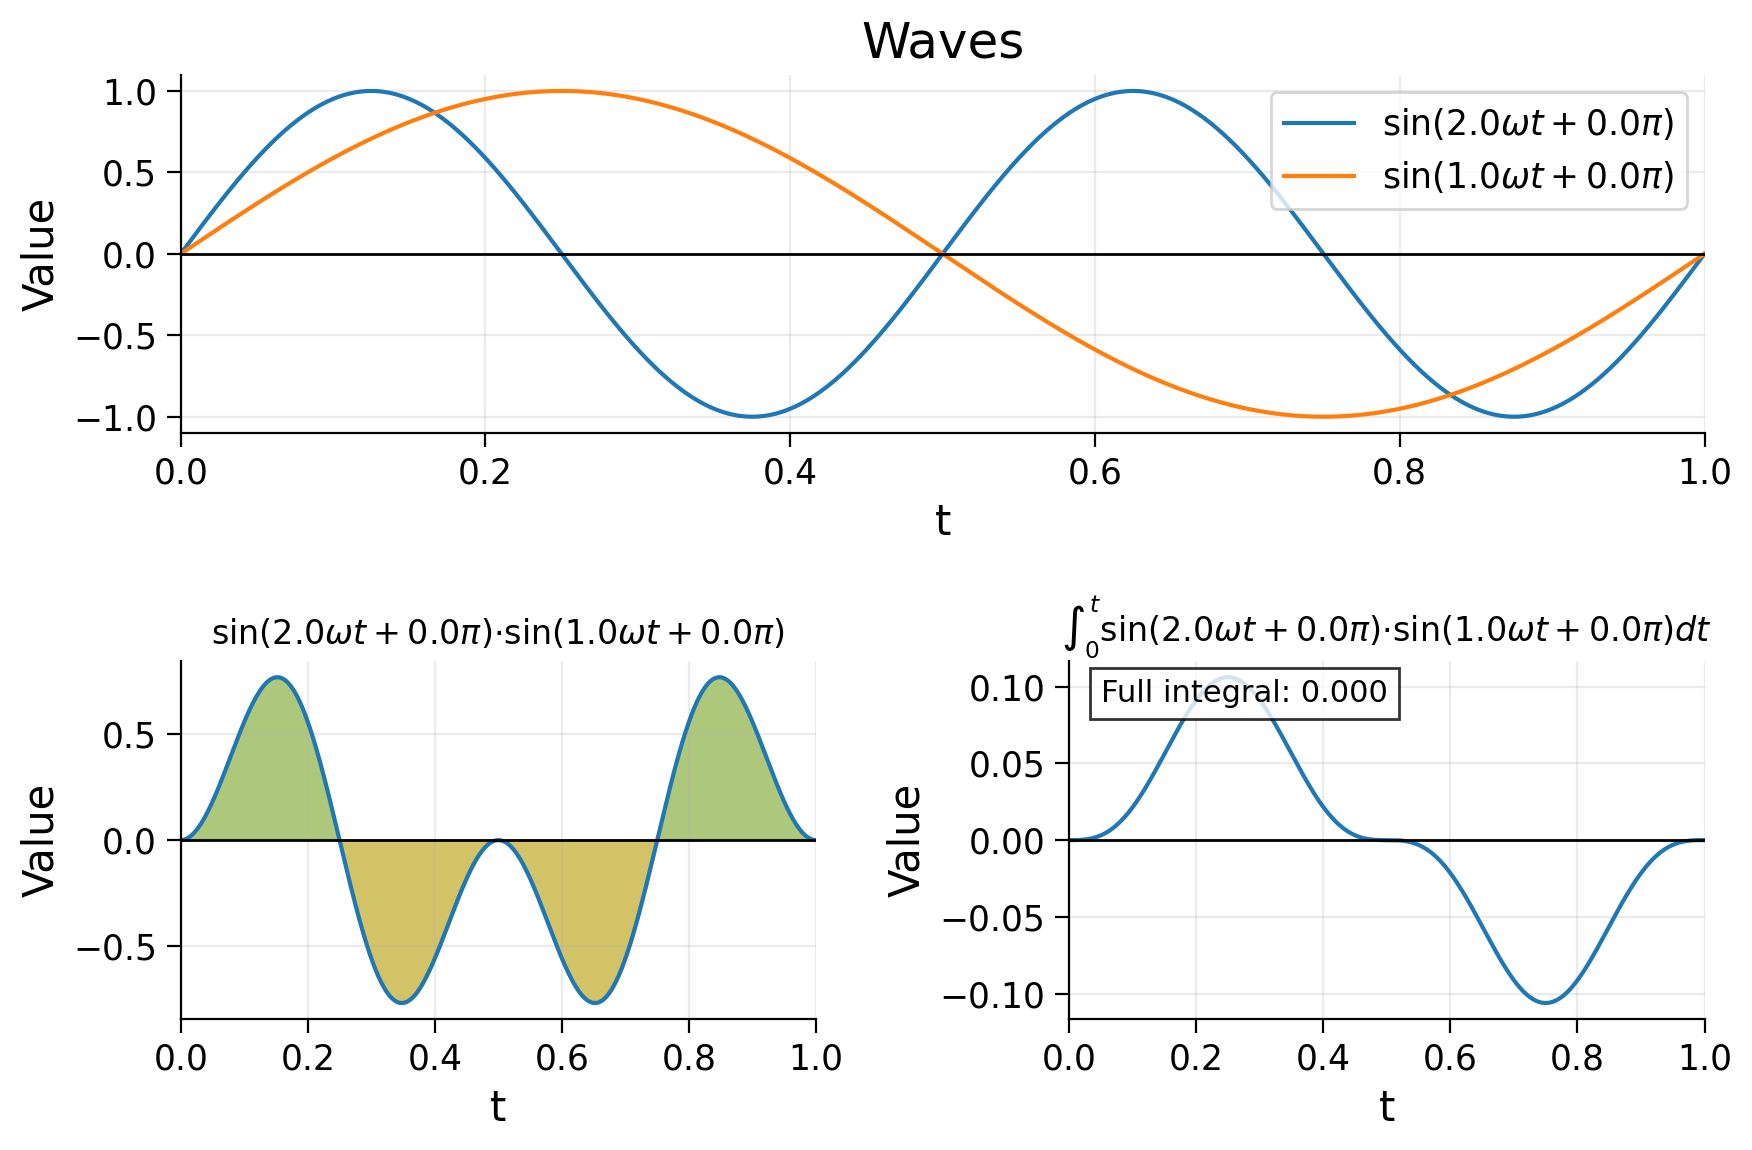

In [32]:
#@markdown Make sure you execute this cell to enable the widget!

def get_function_and_label(mode, n, m, phi1, phi2, T):
    """Helper function to get the waves and the labels
    Inputs:
        mode: "sine-sine", "cosine-cosine" or "sine-cosine"
        n,m: integer numbers for frequencies
        phi1, phi2: phase shift
        T: period
    Returns:
        f1, f2: functions with resepect to chosen mode and arguments n,m,phi1,phi2
        label1, label2: labels for the functions
    """

    omega = 2 * np.pi / T

    if mode == "sine-sine":
        def f1(t):
            return np.sin(omega * n * t + phi1 * np.pi)
        def f2(t):
            return np.sin(omega * m * t + phi2 * np.pi)
        label1 = rf"$\sin({int(n*10)/10}\omega t + {phi1}\pi)$"
        label2 = rf"$\sin({int(m*10)/10}\omega t + {phi2}\pi)$"

    elif mode == "sine-cosine":
        def f1(t):
            return np.sin(omega * n * t + phi1 * np.pi)
        def f2(t):
            return np.cos(omega * m * t + phi2 * np.pi)
        label1 = rf"$\sin({n}\omega t + {phi1}\pi)$"
        label2 = rf"$\cos({m}\omega t + {phi2}\pi)$"

    elif mode == "cosine-cosine":
        def f1(t):
            return np.cos(omega * n * t + phi1 * np.pi)
        def f2(t):
            return np.cos(omega * m * t + phi2 * np.pi)
        label1 = rf"$\cos({n}\omega t + {phi1}\pi)$"
        label2 = rf"$\cos({m}\omega t + {phi2}\pi)$"

    return f1, f2, label1, label2


def plot_all(n=2, m=1, phi1=0, phi2=0, mode="sine-sine"):
    T = 1
    f1, f2, label1, label2 = get_function_and_label(mode, n, m, phi1, phi2, T)

    t = np.linspace(0, T, 1000)
    integrand = lambda t: f1(t) * f2(t)
    integral_scalar = lambda tt: quad(integrand, t[0], tt)[0]
    integral = np.vectorize(integral_scalar)


    # arrange the plots
    fig = plt.figure(figsize=(9, 6))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

    ax1 = fig.add_subplot(gs[0, :])   # top row
    ax2 = fig.add_subplot(gs[1, 0])   # bottom left
    ax3 = fig.add_subplot(gs[1, 1])   # bottom right

    # Row 1: sine/cosine waves
    ax1.plot(t, f1(t), label=label1)
    ax1.plot(t, f2(t), label=label2)
    ax1.legend(loc="upper right")
    ax1.set_xlabel("t")
    ax1.set_ylabel("Value")
    ax1.set_title("Waves")
    ax1.axhline(0, color="black", linewidth=1)
    ax1.grid(alpha=0.25)
    ax1.set_xlim(t[0], t[-1])

    # Row 2 left: integrand
    label_integrand = label1 + r"$\cdot$" + label2
    y = integrand(t)
    ax2.plot(t, y)
    ax2.fill_between(t, y, 0, where=(y >= 0), color="#99BA5A", alpha=0.8)
    ax2.fill_between(t, y, 0, where=(y < 0), color="#C9B541", alpha=0.8)

    ax2.set_xlabel("t")
    ax2.set_ylabel("Value")
    ax2.set_title(label_integrand, fontsize=12)
    ax2.axhline(0, color="black", linewidth=1)
    ax2.grid(alpha=0.25)
    ax2.set_xlim(t[0], t[-1])

    # Row 2 right: cumulative integral
    label_integral = rf"$\int_{{0}}^{{t}}$" + label_integrand + r"$dt$"
    ax3.plot(t, integral(t))
    ax3.set_xlabel("t")
    ax3.set_ylabel("Value")
    ax3.set_title(label_integral, fontsize=12)
    ax3.axhline(0, color="black", linewidth=1)
    ax3.grid(alpha=0.25)
    ax3.set_xlim(t[0], t[-1])
    ax3.text(
        0.05, 0.95,
        f"Full integral: {integral(t[-1]):.3f}",
        transform=ax3.transAxes,
        color="black",
        fontsize=11,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )


    fig.tight_layout()
   plt.show()


### Widgets and Display ###
n_widget = widgets.FloatSlider(value=2, min=-10, max=10, step=0.2, description='n')
m_widget = widgets.FloatSlider(value=1, min=-10, max=10, step=0.2, description='m')
phi1_widget = widgets.FloatSlider(value=0, min=0, max=2, step=0.05, description='phi1')
phi2_widget = widgets.FloatSlider(value=0, min=0, max=2, step=0.05, description='phi2')
mode_widget = widgets.Dropdown(options=["sine-sine", "cosine-cosine", "sine-cosine"], value="sine-sine", description='mode')
controls = widgets.VBox([mode_widget, n_widget, m_widget, phi1_widget, phi2_widget])

output = widgets.interactive_output(
    plot_all,
    {
        'n': n_widget,
        'm': m_widget,
        'phi1': phi1_widget,
        'phi2': phi2_widget,
        'mode': mode_widget
    }
)

ui = widgets.HBox([output, controls])

display(ui)

---

# Part 2: The Fourier Series

*Estimated timing to here from start of tutorial: min*


## Video 3: Building complex signals from sine waves

In [17]:
from IPython.display import HTML
HTML("<div style='background:#eee;padding:1em;border-radius:6px;'>"
     "<b>Video 3 placeholder.</b> Topics: harmonics, Fourier coefficients, convergence, and the Gibbs phenomenon."
     "</div>")

In [18]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Video_3_FourierSeries")

Familiar periodic signals — square waves and sawtooth waves — look nothing like sine waves. Yet every one of them can be written as a (theoretically infinite) sum of sine waves:

$$x(t) = a_1 \sin(2\pi f_0 t) + a_2 \sin(2\pi f_2 t) + a_3 \sin(2\pi f_3 t) + \cdots$$

where the frequencies $f_1, f_2, \ldots$ are **fixed harmonics** of a fundamental frequency $f_0 = 2$ Hz, and the $a_n$ are the **Fourier coefficients** that determine how much of each frequency is present.

Here we look at the **first 5 components** — enough to recognise the shape of each signal.

**Your task:** choose the coefficient for each component using the sliders and try to match the target signal (gray dashed) — the *actual* square / sawtooth wave. With only 5 terms you **cannot** drive the **MSE** all the way to 0; instead, aim for the **best possible 5-term fit**. When your coefficients reach it the badge turns **green**, and the MSE it shows is the leftover **truncation error** — the gap between 5 sine waves and the true wave. (You'll close that gap by adding more terms in the next section.)

> **Hint:** not all coefficients are positive — some components are subtracted rather than added. Look at what happens to the shape in the bottom panel as you go negative.
>
> A **negative coefficient** is equivalent to a positive one with a **phase shift of $\pi$** — the component is simply flipped upside-down. So the sign of a slider tells you the phase: positive means $\phi = 0$, negative means $\phi = \pi$. In the magnitude spectrum the bar height is always the **positive magnitude** $|a_n|$; the sign/phase is shown by the hatch.

## Interactive Demo 3: Building signals from sine waves

In [19]:
# @title Interactive Demo 3: Building signals from sine waves

def build_fourier_builder_demo():
    # ── Instructor config ──
    F0 = 2.0
    DURATION, FS = 1.0, 2000
    t = np.linspace(0, DURATION, int(FS * DURATION), endpoint=False)
    rng = np.random.default_rng()
    RAND_PHASES = rng.uniform(0, 2 * np.pi, 5)

    COMP_COLORS = ['#e85d04', '#7c3aed', '#059669', '#d97706', '#0891b2']

    SIGNAL_DEFS = {
        'Square wave': {
            'harmonics': [1, 3, 5, 7, 9],
            'coeffs':    [4 / (n * np.pi) for n in [1, 3, 5, 7, 9]],
        },
        'Sawtooth wave': {
            'harmonics': [1, 2, 3, 4, 5],
            'coeffs':    [2 * (-1)**(n + 1) / (n * np.pi) for n in [1, 2, 3, 4, 5]],
        },
    }

    def true_signal(signal_type):
        """Analytic ground-truth waveform (amplitude ±1) — the *actual* wave,
        not a Fourier sum. This is what the student's reconstruction is scored
        against, so the displayed MSE never quite reaches 0 with only 5 terms."""
        x = 2 * np.pi * F0 * t
        if signal_type == 'Square wave':
            return np.where(np.sin(x) >= 0, 1.0, -1.0)
        else:  # Sawtooth wave
            return 2 * ((F0 * t + 0.5) % 1.0) - 1.0

    _phases = [0.0] * 5

    img_out = widgets.Image(format='png')


    def build_signal(coeffs, freqs, phases):
        return sum(a * np.sin(2 * np.pi * f * t + phi)
                   for a, f, phi in zip(coeffs, freqs, phases))


    def draw(phases):
        signal_type    = signal_dropdown.value
        defn           = SIGNAL_DEFS[signal_type]
        harmonics      = defn['harmonics']
        freqs          = [n * F0 for n in harmonics]
        true_coeffs    = defn['coeffs']
        student_coeffs = [s.value for s in sliders]

        for slider, n, f in zip(sliders, harmonics, freqs):
            slider.description = f'a{n}  ({f:.0f} Hz)'

        # y_target: the actual analytic wave (gray dashed) — what we score against.
        # y_best:   the best achievable 5-term Fourier fit (true coefficients,
        #           zero phase). Matching it is the goal, and it drives the
        #           green/red trigger exactly as before.
        y_target   = true_signal(signal_type)
        y_best     = build_signal(true_coeffs, freqs, [0.0] * 5)
        y_student  = build_signal(student_coeffs, freqs, phases)
        components = [a * np.sin(2 * np.pi * f * t + phi)
                      for a, f, phi in zip(student_coeffs, freqs, phases)]

        # Displayed MSE: distance to the *actual* wave (floors at the truncation
        # residual, so it stays >0 even for a perfect 5-term fit).
        mse_display = np.mean((y_target - y_student) ** 2)
        # Trigger MSE: distance to the best 5-term fit — "the way it is now".
        mse_trigger = np.mean((y_best - y_student) ** 2)
        is_matched  = mse_trigger < 0.01

        # Phase-independent y-limits: use sum of |coefficients| as upper bound
        # so the axis only moves when magnitudes change, not during phase animation
        y_abs_max = max(
            sum(abs(c) for c in true_coeffs),
            sum(abs(c) for c in student_coeffs),
            float(np.max(np.abs(y_target))),
            0.5
        ) * 1.2
        ylim = (-y_abs_max, y_abs_max)

        # Magnitude spectrum data
        max_h   = max(harmonics)
        all_h   = list(range(1, max_h + 1))
        active  = dict(zip(harmonics, range(len(harmonics))))

        spec_heights = []
        spec_colors  = []
        spec_hatches = []
        spec_labels  = [f'{h*F0:.0f} Hz' for h in all_h]

        for h in all_h:
            if h in active:
                coeff = student_coeffs[active[h]]
                spec_heights.append(abs(coeff))
                spec_colors.append(COMP_COLORS[active[h]])
                spec_hatches.append('///' if coeff < 0 else '')
            else:
                spec_heights.append(0.0)
                spec_colors.append('#dddddd')
                spec_hatches.append('')

        fig = plt.figure(figsize=(12, 9))
        gs      = fig.add_gridspec(2, 2)
        ax_main = fig.add_subplot(gs[0, :])
        ax_comp = fig.add_subplot(gs[1, 0])
        ax_spec = fig.add_subplot(gs[1, 1])

        # ── Top: reconstruction vs the true wave ──────────────
        ax_main.plot(t, y_target, color='#888888', linestyle='--', linewidth=2,
                     label=f'Target (true {signal_type.lower()})', alpha=0.85)
        ax_main.plot(t, y_student, color='#2563EB', linewidth=2,
                     label='Your reconstruction')
        ax_main.set_title(f'{signal_type} — Reconstruction', fontsize=13)
        ax_main.set_xlabel('Time (s)')
        ax_main.set_ylabel('Amplitude')
        ax_main.legend(loc='upper right')
        ax_main.set_xlim(0, DURATION)
        ax_main.set_ylim(ylim)
        ax_main.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

        mse_color = '#16a34a' if is_matched else '#dc2626'
        ax_main.text(0.02, 0.95, f'MSE: {mse_display:.4f}',
                     transform=ax_main.transAxes, fontsize=12, verticalalignment='top',
                     color=mse_color,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                               edgecolor=mse_color, alpha=0.8))

        # ── Bottom-left: components overlaid ─────────────────
        phi_mode = phase_radio.value.startswith('Random')
        for comp, f, coeff, phi, n in zip(components, freqs, student_coeffs, phases, harmonics):
            phi_lbl = f'+φ{n}' if phi_mode and abs(phi) > 1e-3 else ''
            ax_comp.plot(t, comp, color=COMP_COLORS[active[n]], linewidth=1.8,
                         label=f'a{n}={coeff:.2f}·sin(2π·{f:.0f}Hz·t{phi_lbl})')
        ax_comp.set_title('Components', fontsize=12)
        ax_comp.set_xlabel('Time (s)')
        ax_comp.set_ylabel('Amplitude')
        ax_comp.legend(loc='upper right', fontsize=8)
        ax_comp.set_xlim(0, DURATION)
        ax_comp.set_ylim(ylim)
        ax_comp.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

        # ── Bottom-right: magnitude spectrum ──────────────────
        for h, height, color, hatch in zip(all_h, spec_heights, spec_colors, spec_hatches):
            ax_spec.bar(h, height, color=color, width=0.55, alpha=0.85,
                        hatch=hatch, edgecolor='#444444' if hatch else color,
                        linewidth=0.8)

        legend_handles = [
            Patch(facecolor='#aaaaaa', edgecolor='#444444', label='positive amplitude'),
            Patch(facecolor='#aaaaaa', edgecolor='#444444', hatch='///',
                  label='negative amplitude (flipped phase)'),
        ]
        ax_spec.legend(handles=legend_handles, fontsize=8, loc='upper right')

        ax_spec.set_xticks(all_h)
        ax_spec.set_xticklabels(spec_labels, fontsize=8)
        ax_spec.set_title('Magnitude Spectrum', fontsize=12)
        ax_spec.set_ylabel('|Coefficient|')
        ax_spec.set_ylim(0, max(2.2, max(spec_heights) * 1.3))
        ax_spec.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

        fig.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        img_out.value = buf.read()


    def update(_change=None):
        draw(_phases)


    def on_phase_change(change):
        target = list(RAND_PHASES[:5]) if change['new'].startswith('Random') else [0.0] * 5
        n_frames, duration = 20, 1.6
        dt    = duration / n_frames
        start = list(_phases)
        for i in range(1, n_frames + 1):
            alpha = i / n_frames
            for j in range(5):
                _phases[j] = start[j] + alpha * (target[j] - start[j])
            draw(_phases)
            if i < n_frames:
                time.sleep(dt)


    def on_signal_change(change):
        for slider in sliders:
            slider.unobserve(update, names='value')
        for slider in sliders:
            slider.value = 0.0
        for slider in sliders:
            slider.observe(update, names='value')
        update()


    def on_reset(_btn):
        for slider in sliders:
            slider.unobserve(update, names='value')
        for slider in sliders:
            slider.value = 0.0
        for slider in sliders:
            slider.observe(update, names='value')
        update()


    signal_dropdown = widgets.Dropdown(
        options=list(SIGNAL_DEFS.keys()),
        value='Square wave',
        description='Signal type:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='280px')
    )
    sliders = [
        widgets.FloatSlider(
            value=0.0, min=-2.0, max=2.0, step=0.01,
            description='',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='550px'),
            readout_format='.2f'
        )
        for i in range(5)
    ]
    phase_radio = widgets.RadioButtons(
        options=['No phase  (φ = 0)', 'Random phase  (fixed per session)'],
        value='No phase  (φ = 0)',
        description='Phase:',
        style={'description_width': 'initial'}
    )
    reset_btn = widgets.Button(
        description='Reset coefficients',
        button_style='warning',
        layout=widgets.Layout(width='180px')
    )

    signal_dropdown.observe(on_signal_change, names='value')
    phase_radio.observe(on_phase_change, names='value')
    reset_btn.on_click(on_reset)
    for slider in sliders:
        slider.observe(update, names='value')

    note = widgets.HTML(
        value="<i>A <b>negative</b> coefficient flips its component upside-down — "
              "it is the same as a phase shift of π.</i>"
    )

    ui = widgets.VBox([
        widgets.HBox([signal_dropdown, reset_btn]),
        phase_radio,
        note,
        widgets.VBox(sliders),
        img_out
    ])

    display(ui)
    update()


build_fourier_builder_demo()

In [20]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_3_FourierBuilder")

## Think! 3: Look at the spectra

Before moving on, cycle through the two signal types in the demo above and pay attention to the **magnitude spectrum** (bottom-right) and the **signs of the slider values** you needed to match each target. A few things to reflect on:

**1. What do you observe about the *component frequencies* in each wave?**
Which harmonics actually appear? Are all of them used, or only some? Compare the square and sawtooth waves — you should see that one of them uses only *odd* harmonics (1·f₀, 3·f₀, 5·f₀, …) while the other uses *every* harmonic (1·f₀, 2·f₀, 3·f₀, …).

**2. What do you observe about the *pattern of signs* on the weights?**
Are all the coefficients positive, or do some need to be negative? Is there a regular pattern (e.g. + + + +, or + − + −, or all positive)? Remember that a negative coefficient is *not* a different kind of component — it is just the same sine wave with a **phase of π** (i.e. flipped upside-down). So the sign pattern is really a phase pattern.

**3. What do you observe about the *magnitudes* of the weights?**
Are the weights all the same size, or do they shrink as the frequency increases? If they shrink, do they decrease *linearly* (like 1, 1/2, 1/3, 1/4, …) or *faster* (like 1, 1/9, 1/25, …)? This rate of decay is what determines how quickly the Fourier series converges — and it's the reason some waveforms need many more harmonics than others to look "right."

Keep your answers in mind as you move into the next section, where we add more and more components and watch the approximation improve.

In [21]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Think_3_Spectra")

## How Many Components Does It Take?

So far you've been working with just the first **5** Fourier components. But in theory these signals require *infinitely many* — so how much does adding more actually help?

Use the slider below to increase **N**, the number of sine-wave components included in the approximation. The coefficients are set automatically to the correct Fourier values — you're just controlling how many terms to keep. The approximation (blue) is compared against the **true signal** (gray dashed) — the actual square, sawtooth, or Gaussian pulse, not another Fourier sum.

A few things to watch for as you increase N:
- **Sawtooth wave** converges slowly — its coefficients shrink only as 1/n.
- **Square wave** is the most stubborn: you'll notice the "ringing" overshoot near each edge (**Gibbs phenomenon**) that never fully disappears, no matter how many terms you add — it just gets narrower.
- **Gaussian pulse** is something new — an **aperiodic** signal: a single localized bump rather than a repeating wave. Yet it too is *just a sum of plain sine waves*. A sharp, narrow pulse needs **many** harmonics (a broad band of frequencies) to build up; with only a few terms it stays a low, wide blob.

### From magnitude to power

Up to now, the bottom panel has shown a **magnitude** spectrum — the size $|a_n|$ of each component. Here we switch to the **power spectrum**: the power carried by each harmonic, $P_n = |a_n|^2/2$ (the average power of a sine of amplitude $a_n$). Power is what most measurements — and our ears — actually respond to, and squaring exaggerates the tall components and flattens the small ones, so the *shape* of the spectrum stands out. We held this back in the earlier demos to keep the focus on building and reading signals; here it earns its place.

**Why introduce it here?** Because the power spectrum is secretly what the convergence badge has been measuring all along. By **Parseval's theorem**, the total power of a signal equals the sum of its harmonic powers — so the **MSE between your N-term sum and the true signal is exactly the total power of the harmonics you left out**. The bars you drop *are* the error you see; watch the MSE fall as more bars switch on.

**Reading the envelope.** The harmonics are drawn as stems sampling a smooth gray **envelope** — the transform of *one period* of the signal. Its shape says a lot:
- **Square wave** → a **sinc²** envelope: a fat main lobe, then **nulls** (every even harmonic lands exactly in a null, with zero power) and decaying **side lobes** carrying the odd harmonics. Hard edges in time cost you a long, slowly-decaying tail of frequencies. (You'll meet this same sinc again when we get to filtering.)
- **Sawtooth wave** → a smooth **1/f²** roll-off, no nulls — every harmonic present, power shrinking steadily.
- **Gaussian pulse** → a **Gaussian** envelope: smooth, no nulls, falling off fastest of all. A smooth bump needs the *fewest* high frequencies; a sharp edge needs the most.

Use the **Power axis** toggle to switch how the vertical scale is drawn:
- **dB** (decibels — log power against linear frequency): stretches the small values so the square's nulls and side lobes, and the long high-frequency tails, stand out clearly.
- **Log-log** (log power against log frequency): the natural view for **power laws**. A spectrum that falls as $1/f^{\alpha}$ becomes a **straight line of slope $-\alpha$** — the sawtooth is a clean slope $-2$, and the square's side-lobe peaks ride a slope $-2$ line with deep notches between them. The Gaussian, which decays faster than *any* power law, instead **curves over and drops off a cliff**. This is exactly how aperiodic, 1/f-like neural power spectra are read.

**The width slider** (Gaussian only) makes the time–frequency trade-off tangible: **widen** σ and the pulse spreads out in time while its spectrum **narrows** — a broad, smooth bump is built from just a few low frequencies; **shrink** σ and the pulse sharpens while its spectrum **broadens** toward higher frequencies. Time-width and frequency-width move in *opposite* directions ($\Delta t \cdot \Delta f \approx$ constant) — the same reciprocity behind the uncertainty principle. Watch the converged pulse, too: a wide pulse needs only a handful of harmonics, a narrow one needs many.

### Same spectrum, very different signal: phase

Select **Gaussian pulse**, then toggle **Aligned phase → pulse** against **Random phase → noise**. This changes *only* the phases of the components, and it **animates**: you'll watch the sharp pulse smoothly melt into noise (and morph back) while the **power spectrum stays frozen** — the bottom panel never moves. Yet the signal completely changes:

- **Aligned:** all the sine waves crest at the *same instant*, add up constructively, and cancel elsewhere → a single **sharp pulse**.
- **Random:** the *same* amplitudes now crest at scattered times, so the energy smears across the whole window → **noise**.

The power spectrum alone does **not** determine a signal. It tells you *which frequencies and how much* — but it's the **phase** that says *when* things happen. A spike and a burst of noise can have an identical spectrum and differ only in their phases.

In [22]:
# @title Interactive Demo 4: Fourier series convergence

def build_convergence_demo():
    # ── Instructor config ──
    F0 = 2.0                        # fundamental of the square / sawtooth (Hz)
    DURATION, FS = 1.0, 2000
    t = np.linspace(0, DURATION, int(FS * DURATION), endpoint=False)

    GAUSS_F0 = 1.0 / DURATION       # one pulse per window → a single localised bump

    # Fixed random phases so that raising N just adds more scrambled terms.
    _rng        = np.random.default_rng(0)
    RAND_PHASES = _rng.uniform(0, 2 * np.pi, 256)

    # Current Gaussian phases (interpolated during the pulse ↔ noise animation)
    _phases = []

    def gauss_sigma():
        """Gaussian pulse width in seconds, read live from the width slider."""
        return gauss_width_slider.value / 1000.0


    def true_signal(signal_type):
        """Analytic ground-truth waveform."""
        x = 2 * np.pi * F0 * t
        if signal_type == 'Square wave':
            return np.where(np.sin(x) >= 0, 1.0, -1.0)
        elif signal_type == 'Sawtooth wave':
            return 2 * ((F0 * t + 0.5) % 1.0) - 1.0
        else:  # Gaussian pulse — a single narrow, centred bump (an aperiodic transient)
            sigma = gauss_sigma()
            return np.exp(-((t - DURATION / 2) ** 2) / (2 * sigma ** 2))


    def spectrum(signal_type, N):
        """First-N-harmonic description of the signal.

        Every signal is written in the single form
            x(t) = DC + Σ |aₙ|·sin(2π fₙ t + φₙ),
        so the phases can later be swapped for random values *without touching
        the magnitudes* — the heart of the Gaussian phase demo. Returns the
        present harmonics, their frequencies, magnitudes |aₙ|, the aligned
        phases, the DC term, the fundamental, and the full harmonic grid (so the
        square's missing even harmonics can be marked as zeros).
        """
        if signal_type == 'Square wave':
            harm   = [2 * k + 1 for k in range(N)]
            mags   = [4 / (h * np.pi) for h in harm]
            phases = [0.0 for _ in harm]
            dc, fundamental = 0.0, F0
            grid   = list(range(1, harm[-1] + 1))
        elif signal_type == 'Sawtooth wave':
            harm   = list(range(1, N + 1))
            mags   = [2 / (h * np.pi) for h in harm]
            phases = [0.0 if h % 2 == 1 else np.pi for h in harm]   # sign (-1)^(h+1)
            dc, fundamental = 0.0, F0
            grid   = list(harm)
        else:  # Gaussian pulse — true coefficients straight from the FFT
            g          = true_signal('Gaussian pulse')
            coeffs     = np.fft.rfft(g) / len(g)
            harm       = list(range(1, N + 1))
            mags       = [2 * np.abs(coeffs[h]) for h in harm]
            phases     = [np.angle(coeffs[h]) + np.pi / 2 for h in harm]  # cos → sin
            dc, fundamental = float(coeffs[0].real), GAUSS_F0
            grid       = list(harm)
        freqs = [h * fundamental for h in harm]
        return harm, freqs, mags, phases, dc, fundamental, grid


    def envelope_power(signal_type, nu):
        """Continuous power envelope |X(ν)|²/2 that the harmonics sample, as a
        function of (continuous) harmonic number ν. This is the transform of one
        period: a sinc² for the square (boxcar edges → nulls + side lobes), a
        smooth 1/ν² roll-off for the sawtooth ramp, and a Gaussian for the
        Gaussian pulse. The discrete harmonic powers land exactly on it."""
        if signal_type == 'Square wave':
            return 2.0 * np.sinc(nu / 2.0) ** 2          # np.sinc(x)=sin(πx)/(πx)
        elif signal_type == 'Sawtooth wave':
            return 2.0 / (np.pi ** 2 * nu ** 2)
        else:  # Gaussian pulse — width set by the slider
            sigma = gauss_sigma()
            return 4 * np.pi * sigma ** 2 * np.exp(-4 * np.pi ** 2 * sigma ** 2 * nu ** 2)


    def reconstruct(freqs, mags, phases, dc):
        y = np.full_like(t, dc)
        for f, m, p in zip(freqs, mags, phases):
            y = y + m * np.sin(2 * np.pi * f * t + p)
        return y


    def target_phases(N):
        """The Gaussian phase vector for the *current* radio mode at this N."""
        _, _, _, aligned, _, _, _ = spectrum('Gaussian pulse', N)
        if phase_radio.value.startswith('Random'):
            return list(RAND_PHASES[:N])
        return list(aligned)


    conv_dropdown = widgets.Dropdown(
        options=['Square wave', 'Sawtooth wave', 'Gaussian pulse'],
        value='Square wave',
        description='Signal type:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='280px')
    )

    n_slider = widgets.IntSlider(
        value=1, min=1, max=200, step=1,
        description='N components:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px')
    )

    phase_radio = widgets.RadioButtons(
        options=['Aligned phase  → pulse', 'Random phase  → noise'],
        value='Aligned phase  → pulse',
        description='Gaussian phase:',
        style={'description_width': 'initial'},
        disabled=True
    )

    scale_toggle = widgets.ToggleButtons(
        options=['dB', 'Log-log'],
        value='dB',
        description='Power axis:',
        style={'description_width': 'initial'}
    )

    gauss_width_slider = widgets.IntSlider(
        value=8, min=4, max=30, step=1,
        description='Gaussian width σ (ms):',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px'),
        disabled=True
    )

    conv_img = widgets.Image(format='png')


    def draw(gauss_phases):
        signal_type = conv_dropdown.value
        N           = n_slider.value
        is_gauss    = signal_type == 'Gaussian pulse'

        harm, freqs, mags, phases, dc, fundamental, grid = spectrum(signal_type, N)
        recon_phases = gauss_phases if is_gauss else phases
        randomized   = is_gauss and phase_radio.value.startswith('Random')

        y_ref    = true_signal(signal_type)
        y_approx = reconstruct(freqs, mags, recon_phases, dc)
        mse      = np.mean((y_ref - y_approx) ** 2)

        max_h = max(grid)

        fig = plt.figure(figsize=(10, 7.5), constrained_layout=True)
        gs  = fig.add_gridspec(2, 1, height_ratios=[3, 2])
        ax      = fig.add_subplot(gs[0])
        ax_spec = fig.add_subplot(gs[1])

        # ── Top: reconstruction vs the true signal ──
        approx_lbl = (f'{N}-term sum (phases scrambled)' if randomized
                      else f'{N}-term approximation')
        ax.plot(t, y_ref, color='#888888', linestyle='--', linewidth=2,
                label=f'Ground truth {signal_type.lower()}', alpha=0.85)
        ax.plot(t, y_approx, color='#2563EB', linewidth=2, label=approx_lbl)
        gauss_tail = f'  —  σ = {gauss_width_slider.value} ms' if is_gauss else ''
        title_tail = '  —  phases scrambled → noise' if randomized else gauss_tail
        ax.set_title(f'{signal_type} — Fourier Series  (N = {N}){title_tail}', fontsize=13)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.legend(loc='upper right')
        ax.set_xlim(0, DURATION)
        ax.set_ylim((-0.6, 1.25) if is_gauss else (-1.35, 1.35))
        ax.axhline(0, color='#cccccc', linewidth=0.8, zorder=0)

        mse_color = '#16a34a' if mse < 0.005 else '#dc2626'
        ax.text(0.02, 0.95, f'MSE vs ground truth: {mse:.5f}',
                transform=ax.transAxes, fontsize=11, verticalalignment='top',
                color=mse_color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=mse_color, alpha=0.8))

        # ── Bottom: POWER spectrum — discrete harmonics sampling a continuous
        #            envelope (the transform of one period) ──
        powers       = [m ** 2 / 2 for m in mags]            # Pₙ = |aₙ|²/2
        missing_h    = [h for h in grid if h not in set(harm)]
        missing_freq = [h * fundamental for h in missing_h]

        nu       = np.linspace(0.5, max_h + 1, 800)
        env      = envelope_power(signal_type, nu)
        env_freq = nu * fundamental
        pmax     = max(powers) if powers else 1.0

        mode = scale_toggle.value
        if mode == 'dB':
            FLOOR = -40.0
            to_db = lambda P: np.clip(10 * np.log10(np.maximum(np.asarray(P, float), 1e-12) / pmax),
                                      FLOOR, None)
            env_y     = to_db(env)
            present_y = to_db(powers)
            missing_y = np.full(len(missing_freq), FLOOR)
            base      = FLOOR
            ylabel    = 'Power  (dB)'
            xlim      = (0, (max_h + 1) * fundamental)
            ylim      = (FLOOR, 5)
        else:  # Log-log
            floor     = pmax * 1e-5
            env_y     = np.maximum(env, floor)
            present_y = np.maximum(np.asarray(powers, float), floor)
            missing_y = np.full(len(missing_freq), floor)
            base      = floor
            ylabel    = 'Power  (log)'
            xlim      = (min(freqs) * 0.8, (max_h + 1) * fundamental)
            ylim      = (floor, pmax * 2)

        ax_spec.plot(env_freq, env_y, color='#9aa0a6', linewidth=1.6, zorder=1,
                     label='envelope (transform of one period)')
        ax_spec.vlines(freqs, base, present_y, color='#2563EB', linewidth=1.2,
                       alpha=0.55, zorder=2)
        ax_spec.scatter(freqs, present_y, color='#2563EB', s=16, zorder=3,
                        label='harmonic')
        if missing_freq:
            ax_spec.scatter(missing_freq, missing_y, marker='x', color='#888888',
                            s=26, linewidths=1.2, zorder=3,
                            label='zero power (between harmonics)')

        spec_note = '  (identical for pulse and noise)' if is_gauss else ''
        ax_spec.set_title('Power Spectrum of the Components' + spec_note, fontsize=12)
        ax_spec.set_xlabel('Frequency (Hz)')
        ax_spec.set_ylabel(ylabel)
        if mode == 'Log-log':
            ax_spec.set_xscale('log')
            ax_spec.set_yscale('log')
        ax_spec.set_xlim(xlim)
        ax_spec.set_ylim(ylim)
        ax_spec.axhline(base, color='#cccccc', linewidth=0.8, zorder=0)
        ax_spec.legend(loc='upper right', fontsize=8)

        if mode == 'dB':
            # Thinned frequency ticks so large N stays readable (linear-freq view)
            step   = max(1, len(grid) // 10)
            tick_h = grid[::step]
            ax_spec.set_xticks([h * fundamental for h in tick_h])
            ax_spec.set_xticklabels([f'{h*fundamental:.0f}' for h in tick_h], fontsize=8)

        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        conv_img.value = buf.read()


    def update_conv(_change=None):
        # Static redraw (slider / dropdown / scale / width). Refresh the Gaussian
        # phases to match the current radio mode at this N; others ignore them.
        if conv_dropdown.value == 'Gaussian pulse':
            _phases[:] = target_phases(n_slider.value)
        draw(_phases)


    def on_phase_change(change):
        # Animate the Gaussian smoothly between aligned-phase pulse and
        # random-phase noise (both directions). The power spectrum never changes
        # — only the phases morph.
        if conv_dropdown.value != 'Gaussian pulse':
            return
        N      = n_slider.value
        target = target_phases(N)                          # destination (new mode)
        start  = list(_phases) if len(_phases) == N else target_phases(N)

        n_frames, duration = 20, 1.6
        dt = duration / n_frames
        for i in range(1, n_frames + 1):
            a = i / n_frames
            _phases[:] = [s + a * (tt - s) for s, tt in zip(start, target)]
            draw(_phases)
            if i < n_frames:
                time.sleep(dt)


    def on_signal_change(change):
        # The phase + width controls only make sense for the Gaussian pulse
        is_gauss = (change['new'] == 'Gaussian pulse')
        phase_radio.disabled        = not is_gauss
        gauss_width_slider.disabled = not is_gauss
        update_conv()


    conv_dropdown.observe(on_signal_change, names='value')
    n_slider.observe(update_conv, names='value')
    phase_radio.observe(on_phase_change, names='value')
    scale_toggle.observe(update_conv, names='value')
    gauss_width_slider.observe(update_conv, names='value')

    display(widgets.VBox([
        widgets.HBox([conv_dropdown, n_slider]),
        widgets.HBox([phase_radio, scale_toggle]),
        gauss_width_slider,
        conv_img
    ]))
    update_conv()


build_convergence_demo()

In [23]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Demo_4_Convergence")

---

# Summary

In this tutorial you built up the Fourier picture of signals from a single sine wave. You saw that any sine is fixed by its amplitude, frequency, and phase; that signals can be **decomposed** into a weighted sum of sines plus a DC offset; that the **magnitude spectrum** is just those weights indexed by frequency; and that periodic waveforms are **Fourier series** of harmonically related sines, whose coefficient decay governs how fast the approximation converges.


In [24]:
# @title Submit your feedback on this tutorial
content_review(f"{feedback_prefix}_Tutorial")

# Part 3 : Basic Spectral Analysis

## Load IBL Neuropixels Data — Streams directly from DANDI (run me first!)
Streams 2 seconds from subject DY-008, channel 60 (best LFP+spike channel). No large download needed — remfile fetches only the bytes we ask for.

In [5]:
url  = 'https://api.dandiarchive.org/api/assets/604b7457-430e-4160-b7ff-594562d942e3/download/'
f    = h5py.File(remfile.File(url), 'r')
ap   = f['acquisition']['ElectricalSeriesProbe00AP']

In [6]:
ap_fs  = 30000.0       # Hz, confirmed from timestamps
conv   = 2.34375e-06   # to volts
BEST_CH = 60           # channel with clearest LFP structure + spikes
T_DUR   = 2.0          # seconds to stream
i1      = int(T_DUR * ap_fs)
t_ap    = np.arange(i1) / ap_fs

In [7]:
print(f'Streaming {T_DUR}s from channel {BEST_CH} at {ap_fs} Hz...')

# Contiguous slice required by remfile — [:, CH:CH+1] not [:, CH]
raw_ap  = ap['data'][:i1, BEST_CH:BEST_CH+1].astype(float)[:, 0] * conv * 1e6  # µV
raw_ap  = raw_ap - np.mean(raw_ap)  # zero-centre

print(f'Done. Shape: {raw_ap.shape}, duration: {t_ap[-1]:.2f}s')
print(f'Signal range: {raw_ap.min():.1f} to {raw_ap.max():.1f} µV')

Streaming 2.0s from channel 60 at 30000.0 Hz...
Done. Shape: (60000,), duration: 2.00s
Signal range: -344.4 to 185.3 µV


### What is Spectral Analysis?

Spectral analysis is a fundamental technique in signal processing used to understand the frequency content of a signal. Instead of looking at a signal's amplitude changes over time, spectral analysis allows us to see which frequencies are present in the signal and how strong they are. This is particularly useful in fields like neurophysiology  to identify brain rhythms, noise components, or specific neural oscillations.

### How is it done?

The most common method for performing spectral analysis is the **Fast Fourier Transform (FFT)**. The FFT is an efficient algorithm to compute the Discrete Fourier Transform (DFT), which decomposes a signal from its original domain (often time) into a representation in the frequency domain.

Here's a basic overview of the process:

1.  **Time Domain Signal**: We start with a signal recorded over time (e.g., `raw_ap` in our notebook).
2.  **Fast Fourier Transform (FFT)**: We apply the FFT to this time-domain signal. The output of the FFT is a complex-valued array, where each element corresponds to a specific frequency. It essentially tells us the amplitude and phase of each frequency component present in the original signal.
3.  **Frequency Axis (`xf`)**: The `fftfreq` function (from `scipy.fft`) is used to generate the corresponding frequencies for each point in the FFT output.
4.  **Spectrum Calculation**: From the FFT output, we can derive different types of spectra:
    *   **Amplitude Spectrum**: This shows the magnitude (amplitude) of each frequency component. It's calculated as `2.0/N * np.abs(yf[0:N//2])`, where `N` is the number of samples and `yf` is the FFT output. The `2.0/N` scaling normalizes the amplitude, and `[0:N//2]` considers only the positive frequency components (the FFT output is symmetric).
    *   **Power Spectrum**: This shows the power of each frequency component. It's often calculated as the square of the amplitude spectrum, sometimes with an additional normalization (`(1.0/N * np.abs(yf[0:N//2]))**2`). Power spectra are useful because power is additive and directly related to the energy content at each frequency. This is often preferred when comparing the 'strength' of different frequency bands.

By plotting these spectra, we can visually identify dominant frequencies, broadband noise, or other spectral features in the signal.

In [22]:
%matplotlib inline
#switch away from inline plots to allow the widget to capture the plot

In [26]:
# Perform FFT on the raw signal
N = len(raw_ap) # Number of sample points
T = 1.0 / ap_fs # Sample spacing (1/sampling frequency)

yf = fft(raw_ap)
xf = fftfreq(N, T)[:N//2]

def combined_interactive_plot(spectrum_type, x_scale, y_scale):
    fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=False) # sharex=False as x-axes are different (time vs freq)

    # Top Panel: Raw Signal Over Time
    axes[0].plot(t_ap, raw_ap, color='C4', lw=0.6)
    axes[0].set_title('Raw Broadband Signal Over Time')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude (µV)')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Bottom Panel: Spectrum Plot
    plot_xf = xf
    plot_y_data = None
    y_label = ''

    if spectrum_type == 'Amplitude Spectrum':
        plot_y_data = 2.0/N * np.abs(yf[0:N//2])
        y_label = 'Amplitude (µV)'
    else: # Power Spectrum
        # Using the convention from previous notebook cells for consistency
        plot_y_data = (1.0/N * np.abs(yf[0:N//2]))**2
        y_label = 'Power (µV$^2$)'

    # Exclude DC component (0 Hz) if x-axis is logarithmic to avoid issues with log(0)
    if x_scale == 'log':
        # Find the first non-zero frequency to plot
        first_nonzero_freq_idx = np.where(plot_xf > 0)[0]
        if len(first_nonzero_freq_idx) > 0:
            start_idx = first_nonzero_freq_idx[0]
            plot_xf_log = plot_xf[start_idx:]
            plot_y_data_log = plot_y_data[start_idx:]
        else:
            # Fallback for extremely unusual cases, or if xf is all zeros (shouldn't happen with fftfreq)
            plot_xf_log = np.array([1e-6]) # A small positive value to allow log plot
            plot_y_data_log = np.array([0])
        axes[1].plot(plot_xf_log, plot_y_data_log, color='C1')
    else:
        axes[1].plot(plot_xf, plot_y_data, color='C1')

    axes[1].set_title(f'{spectrum_type} of Raw Broadband Signal')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel(y_label)
    axes[1].set_xscale(x_scale)
    axes[1].set_yscale(y_scale)
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show() 

# Create widgets for user control
spectrum_type_widget = widgets.RadioButtons(
    options=['Amplitude Spectrum', 'Power Spectrum'],
    value='Amplitude Spectrum',
    description='Spectrum Type:',
    disabled=False,
    layout=widgets.Layout(width='auto')
)

x_scale_widget = widgets.RadioButtons(
    options=['linear', 'log'],
    value='linear',
    description='X-axis Scale:   ',
    disabled=False,
    layout=widgets.Layout(width='auto')
)

y_scale_widget = widgets.RadioButtons(
    options=['linear', 'log'],
    value='linear',
    description='Y-axis Scale:   ',
    disabled=False,
    layout=widgets.Layout(width='auto')
)

# The interactive_output itself is a widget that captures the plot
output_plot = widgets.interactive_output(combined_interactive_plot, {
    'spectrum_type': spectrum_type_widget,
    'x_scale': x_scale_widget,
    'y_scale': y_scale_widget
})


In [27]:
# @title Arrange the widgets and the plot output in a VBox
display(widgets.VBox([
    output_plot, # The actual plot output from interactive_output
    widgets.HBox([spectrum_type_widget, x_scale_widget, y_scale_widget]) # Controls second
]))